In [ ]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np

def get_dataframe_from_records(records):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def get_records(project, metrics=[]):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    runs = api.runs(f"{entity}/{project}")

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not run.group or not run.group.startswith("best_"):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        records.append(record)
    return records

def style_mean_column(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    top2_idx = mean_vals.nlargest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles


In [29]:
ft_groups = ['best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_xlstm_sup']

# PTB-XL metrics

In [41]:
metrics = ["test_acc", "test_f1", "test_auroc", "test_auprc"]
records_ptb_xl = get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=metrics)
formatted_df = get_dataframe_from_records(records_ptb_xl)

100%|██████████| 466/466 [01:11<00:00,  6.55it/s]


## Finetuning

In [ ]:
# ands with _ft or _sup
ptbxl_ft = formatted_df[formatted_df.index.isin(ft_groups)]
styled_df = ptbxl_ft.style.apply(style_mean_column)
styled_df

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.891 ± 0.001,0.734 ± 0.002,0.930 ± 0.000,0.822 ± 0.001
best_jepa_ft,0.884 ± 0.001,0.733 ± 0.003,0.923 ± 0.000,0.809 ± 0.000
best_stmem_ft,0.892 ± 0.001,0.739 ± 0.005,0.930 ± 0.001,0.822 ± 0.002
best_trans_ft,0.880 ± 0.002,0.710 ± 0.017,0.925 ± 0.001,0.808 ± 0.001
best_xlstm_ft,0.885 ± 0.001,0.720 ± 0.013,0.928 ± 0.001,0.817 ± 0.003
best_xlstm_sup,0.860 ± 0.005,0.667 ± 0.007,0.891 ± 0.004,0.748 ± 0.006


## Linear probing

In [32]:
agg_df_full_lp = formatted_df[formatted_df.index.str.endswith("_lp")]
styled_df_lp = agg_df_full_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.883 ± 0.001,0.702 ± 0.002,0.917 ± 0.000,0.799 ± 0.000
best_jepa_lp,0.864 ± 0.001,0.712 ± 0.002,0.902 ± 0.000,0.769 ± 0.000
best_stmem_lp,0.847 ± 0.001,0.564 ± 0.002,0.867 ± 0.001,0.693 ± 0.001
best_trans_lp,0.875 ± 0.001,0.703 ± 0.002,0.914 ± 0.000,0.782 ± 0.001
best_xlstm_lp,0.876 ± 0.001,0.690 ± 0.001,0.915 ± 0.000,0.788 ± 0.001


## Linear probing 10%

In [5]:
agg_df_10 = formatted_df[formatted_df.index.str.endswith("_10")]
styled_df_10 = agg_df_10.style.apply(style_mean_column)
styled_df_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp_10,0.868 ± 0.001,0.616 ± 0.006,0.891 ± 0.001,0.745 ± 0.004
best_jepa_lp_10,0.789 ± 0.003,0.638 ± 0.003,0.878 ± 0.002,0.711 ± 0.011
best_stmem_lp_10,0.808 ± 0.001,0.314 ± 0.015,0.816 ± 0.002,0.565 ± 0.007
best_trans_lp_10,0.862 ± 0.001,0.663 ± 0.004,0.893 ± 0.001,0.741 ± 0.002
best_xlstm_lp_10,0.859 ± 0.002,0.613 ± 0.002,0.884 ± 0.002,0.718 ± 0.010


## Linear probing 1%

In [6]:
agg_df_1 = formatted_df[formatted_df.index.str.endswith("_1")]
styled_df_1 = agg_df_1.style.apply(style_mean_column)
styled_df_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp_1,0.849 ± 0.005,0.623 ± 0.012,0.864 ± 0.007,0.678 ± 0.019
best_jepa_lp_1,0.722 ± 0.012,0.571 ± 0.010,0.825 ± 0.008,0.615 ± 0.018
best_stmem_lp_1,0.799 ± 0.003,0.343 ± 0.014,0.769 ± 0.004,0.506 ± 0.009
best_trans_lp_1,0.749 ± 0.015,0.595 ± 0.009,0.841 ± 0.006,0.633 ± 0.010
best_xlstm_lp_1,0.827 ± 0.007,0.526 ± 0.042,0.836 ± 0.008,0.621 ± 0.009


# CPSC 2018

In [7]:
records_cpsc = get_records("train-cpsc2018-multilabel", metrics=["test_acc", "test_f1", "test_auroc", "test_auprc"])
formatted_df_cpsc = get_dataframe_from_records(records_cpsc)

100%|██████████| 307/307 [00:43<00:00,  7.02it/s]


## Finetuning

In [ ]:
cpsc_ft = formatted_df_cpsc[formatted_df_cpsc.index.isin(ft_groups)]

styled_df_ft = cpsc_ft.style.apply(style_mean_column)
styled_df_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.964 ± 0.000,0.794 ± 0.005,0.969 ± 0.001,0.854 ± 0.002
best_jepa_ft,0.942 ± 0.003,0.749 ± 0.009,0.965 ± 0.001,0.842 ± 0.003
best_stmem_ft,0.963 ± 0.001,0.789 ± 0.012,0.958 ± 0.003,0.835 ± 0.011
best_trans_ft,0.961 ± 0.001,0.796 ± 0.008,0.965 ± 0.003,0.853 ± 0.006
best_xlstm_ft,0.968 ± 0.001,0.822 ± 0.008,0.981 ± 0.001,0.888 ± 0.003
best_xlstm_sup,0.952 ± 0.001,0.719 ± 0.008,0.951 ± 0.002,0.813 ± 0.006


## Linear probing

In [9]:
formatted_df_cpsc_lp = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_lp")]
styled_df_lp = formatted_df_cpsc_lp.style.apply(style_mean_column)
styled_df_lp


,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.958 ± 0.000,0.750 ± 0.007,0.962 ± 0.000,0.830 ± 0.001
best_jepa_lp,0.889 ± 0.002,0.613 ± 0.003,0.961 ± 0.000,0.830 ± 0.001
best_stmem_lp,0.935 ± 0.000,0.455 ± 0.005,0.922 ± 0.001,0.722 ± 0.004
best_trans_lp,0.953 ± 0.001,0.733 ± 0.008,0.951 ± 0.001,0.787 ± 0.008
best_xlstm_lp,0.961 ± 0.002,0.781 ± 0.011,0.968 ± 0.001,0.861 ± 0.004


## Linear probing 10%


In [10]:
formatted_df_cpsc_10 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_10")]
styled_df_cpsc_10 = formatted_df_cpsc_10.style.apply(style_mean_column)
styled_df_cpsc_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp_10,0.913 ± 0.002,0.182 ± 0.011,0.919 ± 0.003,0.672 ± 0.012
best_jepa_lp_10,0.748 ± 0.004,0.451 ± 0.003,0.934 ± 0.007,0.763 ± 0.013
best_stmem_lp_10,0.885 ± 0.003,0.027 ± 0.016,0.798 ± 0.010,0.448 ± 0.005
best_trans_lp_10,0.789 ± 0.013,0.461 ± 0.011,0.898 ± 0.006,0.653 ± 0.012
best_xlstm_lp_10,0.930 ± 0.002,0.406 ± 0.025,0.913 ± 0.007,0.689 ± 0.027


## Linear probing 1%

In [11]:
formatted_df_cpsc_1 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_1")]
styled_df_cpsc_1 = formatted_df_cpsc_1.style.apply(style_mean_column)
styled_df_cpsc_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std)
,,,,
group,,,,
best_ecgfm_lp_1,0.933 ± 0.005,0.481 ± 0.073,0.920 ± 0.007,0.678 ± 0.012
best_jepa_lp_1,0.674 ± 0.007,0.384 ± 0.007,0.878 ± 0.010,0.598 ± 0.020
best_stmem_lp_1,0.908 ± 0.006,0.250 ± 0.043,0.827 ± 0.012,0.479 ± 0.024
best_trans_lp_1,0.714 ± 0.021,0.389 ± 0.017,0.827 ± 0.013,0.515 ± 0.011
best_xlstm_lp_1,0.915 ± 0.010,0.401 ± 0.086,0.873 ± 0.015,0.591 ± 0.029


# MIT-BIH classification

In [12]:
records_mit_cls = get_records("train-mitbih-5", metrics=["test_acc", "test_sensitivity/mean", "test_ppv/mean", "test_specificity/mean", "test_f1/mean"])
formatted_df_mit_cls = get_dataframe_from_records(records_mit_cls)

100%|██████████| 279/279 [00:39<00:00,  7.01it/s]


## Finetuning

In [33]:
mit_ft = formatted_df_mit_cls[formatted_df_mit_cls.index.isin(ft_groups)]

styled_df_mit_ft = mit_ft.style.apply(style_mean_column)
styled_df_mit_ft

,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std)
,,,,,
group,,,,,
best_ecgfm_ft,0.863 ± 0.008,0.211 ± 0.002,0.207 ± 0.002,0.809 ± 0.002,0.207 ± 0.002
best_jepa_ft,0.954 ± 0.001,0.555 ± 0.007,0.626 ± 0.007,0.950 ± 0.001,0.581 ± 0.007
best_stmem_ft,0.967 ± 0.002,0.624 ± 0.007,0.671 ± 0.013,0.964 ± 0.003,0.644 ± 0.007
best_trans_ft,0.896 ± 0.008,0.475 ± 0.002,0.457 ± 0.005,0.905 ± 0.001,0.425 ± 0.006
best_xlstm_ft,0.976 ± 0.007,0.651 ± 0.035,0.721 ± 0.019,0.973 ± 0.010,0.677 ± 0.025
best_xlstm_sup,0.896 ± 0.013,0.448 ± 0.028,0.416 ± 0.020,0.910 ± 0.004,0.402 ± 0.014


## Linear probing

In [14]:
formatted_mit_lp = formatted_df_mit_cls[formatted_df_mit_cls.index.str.endswith("_lp")]
styled_df_mit_lp = formatted_mit_lp.style.apply(style_mean_column)
styled_df_mit_lp


,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp,0.869 ± 0.012,0.210 ± 0.003,0.210 ± 0.004,0.807 ± 0.003,0.206 ± 0.004
best_jepa_lp,0.946 ± 0.000,0.470 ± 0.003,0.574 ± 0.003,0.933 ± 0.000,0.496 ± 0.003
best_stmem_lp,0.936 ± 0.003,0.414 ± 0.012,0.503 ± 0.032,0.920 ± 0.002,0.424 ± 0.019
best_trans_lp,0.931 ± 0.000,0.381 ± 0.004,0.549 ± 0.012,0.924 ± 0.004,0.395 ± 0.005
best_xlstm_lp,0.972 ± 0.002,0.686 ± 0.021,0.669 ± 0.014,0.976 ± 0.003,0.674 ± 0.013


# MIT-BIH r-peaks

In [15]:
records_mit_r_peaks = get_records("train-mitbih-r_peaks", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance"])
formatted_df_mit_r_peaks = get_dataframe_from_records(records_mit_r_peaks)

100%|██████████| 133/133 [00:14<00:00,  9.17it/s]


## Fine-tuning

In [34]:
mit_r_peaks_ft = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.isin(ft_groups)]
# add sup rows to ft
styled_df_mit_r_peaks_ft = mit_r_peaks_ft.style.apply(style_mean_column)
styled_df_mit_r_peaks_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std)
,,,
group,,,
best_ecgfm_ft,0.081 ± 0.006,0.011 ± 0.001,3794.272 ± 789.848
best_jepa_ft,0.996 ± 0.000,0.909 ± 0.004,4.195 ± 0.059
best_stmem_ft,0.994 ± 0.001,0.937 ± 0.001,5.148 ± 0.403
best_trans_ft,0.983 ± 0.001,0.900 ± 0.001,7.587 ± 0.159
best_xlstm_ft,0.995 ± 0.000,0.921 ± 0.001,5.208 ± 0.098
best_xlstm_sup,0.980 ± 0.007,0.889 ± 0.012,8.217 ± 1.056


## Linear probing

In [17]:
formatted_df_mit_r_peaks_lp = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.str.endswith("_lp")]
styled_df_mit_r_peaks_lp = formatted_df_mit_r_peaks_lp.style.apply(style_mean_column)
styled_df_mit_r_peaks_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std)
,,,
group,,,
best_ecgfm_lp,0.073 ± 0.005,0.010 ± 0.001,4564.209 ± 630.534
best_jepa_lp,0.976 ± 0.000,0.444 ± 0.001,6.858 ± 0.016
best_stmem_lp,0.970 ± 0.001,0.564 ± 0.002,7.430 ± 0.139
best_trans_lp,0.864 ± 0.001,0.476 ± 0.000,32.177 ± 0.086
best_xlstm_lp,0.945 ± 0.005,0.590 ± 0.011,11.487 ± 0.283


# Exercise high intensity r peaks

In [18]:
records_exe_r = get_records("train-exercise-r_peak", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance"])
formatted_df_exe_r = get_dataframe_from_records(records_exe_r)

100%|██████████| 137/137 [00:15<00:00,  9.01it/s]

In [19]:
# print all groups
print("Groups in formatted_df_exe_r:")
print(formatted_df_exe_r.index.tolist())

Groups in formatted_df_exe_r:
['best_ecgfm_ft', 'best_ecgfm_lp', 'best_jepa_ft', 'best_jepa_lp', 'best_stmem_ft', 'best_stmem_lp', 'best_trans_ft', 'best_trans_lp', 'best_xlstm_ft', 'best_xlstm_lp', 'best_xlstm_sup']


# Finetuning

In [35]:
exe_r_ft = formatted_df_exe_r[formatted_df_exe_r.index.isin(ft_groups)]
# add sup rows to ft
styled_df_exe_r_ft = exe_r_ft.style.apply(style_mean_column)
styled_df_exe_r_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std)
,,,
group,,,
best_ecgfm_ft,0.426 ± 0.006,0.082 ± 0.005,53.058 ± 1.501
best_jepa_ft,0.975 ± 0.002,0.857 ± 0.008,3.716 ± 0.161
best_stmem_ft,0.988 ± 0.002,0.986 ± 0.001,3.284 ± 0.456
best_trans_ft,0.850 ± 0.006,0.631 ± 0.011,12.475 ± 0.484
best_xlstm_ft,0.996 ± 0.001,0.968 ± 0.002,3.983 ± 0.231
best_xlstm_sup,0.990 ± 0.002,0.966 ± 0.002,5.832 ± 0.507


# Linear probing

In [21]:
formatted_exe_r_lp = formatted_df_exe_r[formatted_df_exe_r.index.str.endswith("_lp")]
styled_df_exe_r_lp = formatted_exe_r_lp.style.apply(style_mean_column)
styled_df_exe_r_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std)
,,,
group,,,
best_ecgfm_lp,0.420 ± 0.016,0.082 ± 0.002,52.658 ± 3.061
best_jepa_lp,0.924 ± 0.004,0.525 ± 0.007,13.473 ± 0.940
best_stmem_lp,0.822 ± 0.018,0.627 ± 0.008,44.091 ± 10.828
best_trans_lp,0.605 ± 0.006,0.302 ± 0.002,25.289 ± 0.381
best_xlstm_lp,0.948 ± 0.004,0.891 ± 0.004,17.983 ± 1.049


# Sleep apnea

In [22]:
records_sleep_apnea = get_records("train-sleep-apnea", metrics=["test_acc", "test_f1", "test_auc"])
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)

100%|██████████| 203/203 [00:26<00:00,  7.76it/s]


# Fine-tuning

In [36]:
sleep_ft = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.isin(ft_groups)]
# add sup rows to ft
styled_df_sleep_ft = sleep_ft.style.apply(style_mean_column)
styled_df_sleep_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std)
,,,
group,,,
best_ecgfm_ft,0.575 ± 0.018,0.566 ± 0.017,0.580 ± 0.021
best_jepa_ft,0.612 ± 0.037,0.592 ± 0.032,0.587 ± 0.032
best_stmem_ft,0.604 ± 0.029,0.600 ± 0.033,0.727 ± 0.035
best_trans_ft,0.563 ± 0.033,0.558 ± 0.030,0.604 ± 0.058
best_xlstm_ft,0.853 ± 0.007,0.802 ± 0.011,0.869 ± 0.004
best_xlstm_sup,0.763 ± 0.036,0.685 ± 0.044,0.783 ± 0.043


# Linear probing

In [24]:
formatted_sleep_lp = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.str.endswith("_lp")]
styled_df_sleep_lp = formatted_sleep_lp.style.apply(style_mean_column)
styled_df_sleep_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std)
,,,
group,,,
best_ecgfm_lp,0.555 ± 0.060,0.548 ± 0.067,0.579 ± 0.082
best_jepa_lp,0.481 ± 0.018,0.468 ± 0.028,0.546 ± 0.006
best_stmem_lp,0.621 ± 0.018,0.616 ± 0.020,0.642 ± 0.030
best_trans_lp,0.683 ± 0.025,0.656 ± 0.028,0.649 ± 0.029
best_xlstm_lp,0.731 ± 0.021,0.612 ± 0.075,0.798 ± 0.018


# PPG

In [25]:
records_ppg = get_records("train-deepbeat", metrics=["test_acc", "test_f1", "test_auroc"])
formatted_df_ppg = get_dataframe_from_records(records_ppg)

100%|██████████| 190/190 [00:24<00:00,  7.80it/s]


## Fine-tuning

In [37]:
ppg_ft = formatted_df_ppg[formatted_df_ppg.index.isin(ft_groups)]
styled_df_ppg_ft = ppg_ft.style.apply(style_mean_column)
styled_df_ppg_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std)
,,,
group,,,
best_ecgfm_ft,0.722 ± 0.048,0.686 ± 0.031,0.846 ± 0.012
best_jepa_ft,0.700 ± 0.039,0.660 ± 0.026,0.817 ± 0.024
best_stmem_ft,0.616 ± 0.065,0.555 ± 0.030,0.643 ± 0.049
best_trans_ft,0.657 ± 0.040,0.623 ± 0.027,0.774 ± 0.021
best_xlstm_ft,0.773 ± 0.033,0.736 ± 0.023,0.891 ± 0.015
best_xlstm_sup,0.771 ± 0.016,0.733 ± 0.012,0.876 ± 0.006


## Linear probing

In [27]:
formatted_df_ppg_lp = formatted_df_ppg[formatted_df_ppg.index.str.endswith("_lp")]
styled_df_ppg_lp = formatted_df_ppg_lp.style.apply(style_mean_column)
styled_df_ppg_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std)
,,,
group,,,
best_ecgfm_lp,0.714 ± 0.064,0.491 ± 0.072,0.641 ± 0.019
best_jepa_lp,0.520 ± 0.009,0.447 ± 0.010,0.477 ± 0.007
best_stmem_lp,0.667 ± 0.048,0.560 ± 0.018,0.653 ± 0.006
best_trans_lp,0.618 ± 0.034,0.562 ± 0.010,0.656 ± 0.003
best_xlstm_lp,0.701 ± 0.061,0.616 ± 0.034,0.751 ± 0.013


# RANKING

In [54]:
ptb_df = pd.DataFrame(records_ptb_xl)
ptb_df = ptb_df.groupby("group").agg('mean')
ptb_df = ptb_df[ptb_df.index.isin(ft_groups)]

cpsc_df = pd.DataFrame(records_cpsc)
cpsc_df = cpsc_df.groupby("group").agg('mean')
cpsc_df = cpsc_df[cpsc_df.index.isin(ft_groups)]

mit_df = pd.DataFrame(records_mit_cls)
mit_df = mit_df.groupby("group").agg('mean')
mit_df = mit_df[mit_df.index.isin(ft_groups)]

mit_r_peaks_df = pd.DataFrame(records_mit_r_peaks)
mit_r_peaks_df = mit_r_peaks_df.groupby("group").agg('mean')
mit_r_peaks_df = mit_r_peaks_df[mit_r_peaks_df.index.isin(ft_groups)]

exe_r_df = pd.DataFrame(records_exe_r)
exe_r_df = exe_r_df.groupby("group").agg('mean')
exe_r_df = exe_r_df[exe_r_df.index.isin(ft_groups)] 

sleep_df = pd.DataFrame(records_sleep_apnea)
sleep_df = sleep_df.groupby("group").agg('mean')
sleep_df = sleep_df[sleep_df.index.isin(ft_groups)]

ppg_df = pd.DataFrame(records_ppg)
ppg_df = ppg_df.groupby("group").agg('mean') 
ppg_df = ppg_df[ppg_df.index.isin(ft_groups)]


In [63]:
categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep<br>Apnea', 'PPG', 'Exercise', 'R-PEAK']
methods = ['ST-MEM', 'ECG-JEPA', 'ECG Founder', 'ours (transformer)', 'ours(xlstm)', 'supervised(xlstm)']

data = {
    'PTB-XL / AUC': [   ptb_df.loc['best_stmem_ft']['test_auroc'],
                        ptb_df.loc['best_jepa_ft']['test_auroc'], 
                        ptb_df.loc['best_ecgfm_ft']['test_auroc'], 
                        ptb_df.loc['best_trans_ft']['test_auroc'], 
                        ptb_df.loc['best_xlstm_ft']['test_auroc'],
                        ptb_df.loc['best_xlstm_sup']['test_auroc']],
    'CPSC2018 / AUC': [ cpsc_df.loc['best_stmem_ft']['test_auroc'],
                        cpsc_df.loc['best_jepa_ft']['test_auroc'], 
                        cpsc_df.loc['best_ecgfm_ft']['test_auroc'],
                        cpsc_df.loc['best_trans_ft']['test_auroc'],
                        cpsc_df.loc['best_xlstm_ft']['test_auroc'],
                        cpsc_df.loc['best_xlstm_sup']['test_auroc']],
    'MIT-BIH / F1': [   mit_df.loc['best_stmem_ft']['test_f1/mean'],
                        mit_df.loc['best_jepa_ft']['test_f1/mean'], 
                        mit_df.loc['best_ecgfm_ft']['test_f1/mean'],
                        mit_df.loc['best_trans_ft']['test_f1/mean'],
                        mit_df.loc['best_xlstm_ft']['test_f1/mean'],
                        mit_df.loc['best_xlstm_sup']['test_f1/mean']],
    'Sleep Apnea / AUC': [ sleep_df.loc['best_stmem_ft']['test_auc'],
                           sleep_df.loc['best_jepa_ft']['test_auc'], 
                           sleep_df.loc['best_ecgfm_ft']['test_auc'],
                           sleep_df.loc['best_trans_ft']['test_auc'],
                           sleep_df.loc['best_xlstm_ft']['test_auc'],
                           sleep_df.loc['best_xlstm_sup']['test_auc']],
    'PPG / AUC': [      ppg_df.loc['best_stmem_ft']['test_auroc'],
                        ppg_df.loc['best_jepa_ft']['test_auroc'], 
                        ppg_df.loc['best_ecgfm_ft']['test_auroc'],
                        ppg_df.loc['best_trans_ft']['test_auroc'],
                        ppg_df.loc['best_xlstm_ft']['test_auroc'],
                        ppg_df.loc['best_xlstm_sup']['test_auroc']],
    'Exercise / F1': [  exe_r_df.loc['best_stmem_ft']['test_f1_20'],
                        exe_r_df.loc['best_jepa_ft']['test_f1_20'], 
                        exe_r_df.loc['best_ecgfm_ft']['test_f1_20'],
                        exe_r_df.loc['best_trans_ft']['test_f1_20'],
                        exe_r_df.loc['best_xlstm_ft']['test_f1_20'],
                        exe_r_df.loc['best_xlstm_sup']['test_f1_20']],
    'R-Peaks / F1': [  mit_r_peaks_df.loc['best_stmem_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_jepa_ft']['test_f1_20'], 
                        mit_r_peaks_df.loc['best_ecgfm_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_trans_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_xlstm_ft']['test_f1_20'],
                        mit_r_peaks_df.loc['best_xlstm_sup']['test_f1_20']],
}# RANKING

df_raw = pd.DataFrame(data, index=methods)
df_raw.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1
ST-MEM,0.929916,0.958217,0.644478,0.727026,0.642692,0.985623,0.937266
ECG-JEPA,0.923336,0.965220,0.580663,0.587402,0.817191,0.857412,0.909293
ECG Founder,0.930447,0.969354,0.207143,0.580191,0.845594,0.081849,0.011331
ours (transformer),0.924652,0.965467,0.425415,0.604085,0.774292,0.631201,0.900353
ours(xlstm),0.927799,0.981308,0.677293,0.868879,0.890624,0.968012,0.920580
supervised(xlstm),0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045


In [79]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import numpy as np

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

rows = 3
cols = 2

min_v = 0. # df_raw.min().min()
max_v = 1.# df_raw.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_raw)
rows = 2
cols = 3
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}],
           [{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=df_raw.index.tolist(),
    vertical_spacing=.1,  # Add vertical spacing between subplots
    horizontal_spacing=0.15  # Add horizontal spacing between subplots
)

pastel_colors = qualitative.Plotly[:len(df_raw)]
gap = 1.0 / num_methods
padding = 0.06

for i, (idx, row) in enumerate(df_raw.iterrows()):

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=3, color=pastel_colors[i]),
            hoverinfo='skip',
        ),
        row=current_row, col=current_col
    )


    # Update polar layout for each subplot
    fig.update_layout({
        f'polar{i+1}': dict(
            angularaxis=dict(rotation=10),  # keep your rotation
            radialaxis=dict(
                visible=True, 
                range=[min_v, max_v], 
                showticklabels=False, 
                showline=False,
                showgrid=True,
            )
        )
    })


# Optional: adjust overall layout for better spacing
fig.update_layout(
    width=18,   # 88mm in pixels (88mm * 2.835 pixels/mm)
    # height=166.3,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
    font=dict(family="Helvetica", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
    showlegend=False,  # Hide legend since each subplot is labeled
    margin=dict(l=50, r=50, t=20, b=20)  # Tight margins for Nature format
)

fig.update_annotations(
    font=dict(size=14, family="Helvetica"),
    showarrow=False,
    #yshift=5,  # Adjust vertical position of titles
)


# save pdf
fig.write_image("radar_chart_methods.pdf")
# fig.show()

Min value: 0.0, Max value: 1.0


['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']


/tmp/ipykernel_10709/3701491394.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10709/3701491394.py:33: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



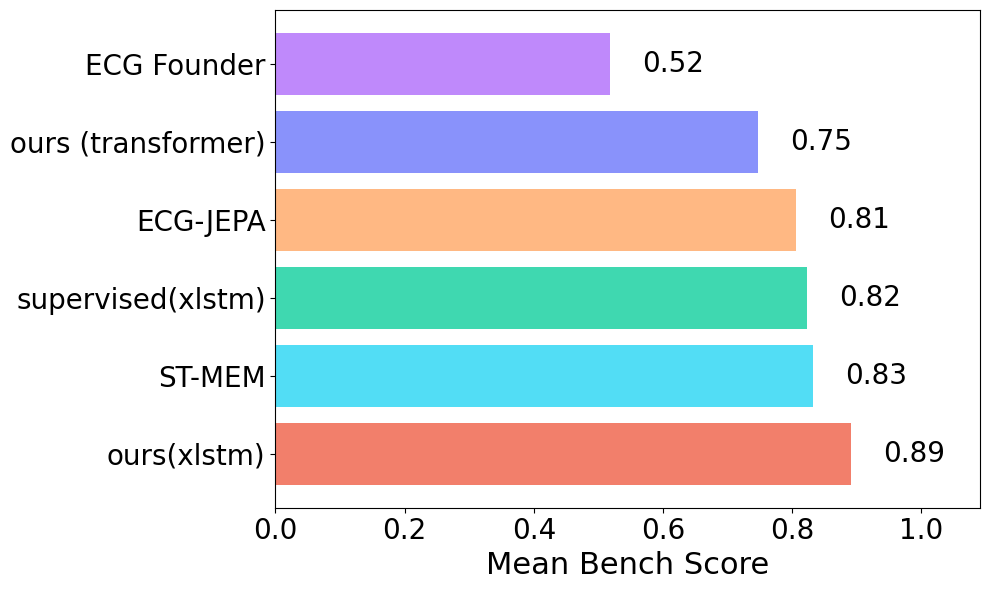

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

# Prepare data
df_ranked_sorted = df_raw.copy()
df_ranked_sorted["mean_rank"] = df_ranked_sorted.mean(axis=1)
df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

# Set style
# sns.set(style="whitegrid")

pastel_colors = qualitative.Plotly[:len(df_ranked_sorted)]
# convert to hex
print(pastel_colors)
# change indexes 
pastel_colors = [pastel_colors[i] for i in [3, 0, 4, 2, 5, 1]]
# add some alpha for better visibility
pastel_colors = [f"{color}c0" for color in pastel_colors]  #

# Generate color gradient
norm = plt.Normalize(df_ranked_sorted["mean_rank"].min(), df_ranked_sorted["mean_rank"].max())
colors = pastel_colors

fig, ax = plt.subplots(figsize=(10, 6))

# Draw horizontal bars
bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color=colors)
ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

# Add labels to bars
for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_rank"], df_ranked_sorted.index)):
    ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

# Format plot
ax.set_xlabel('Mean Bench Score', fontsize=22)
#ax.set_ylabel('Method', fontsize=12)
# ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
ax.invert_yaxis()  # Highest rank at top
ax.set_xlim([0, df_ranked_sorted["mean_rank"].max() + 0.2])  # Adjust x-axis limit
# ax.xaxis.set_minor_locator(MultipleLocator(250))

# ax.grid(True, axis='x', linestyle='--', alpha=0.7)
# ax.set_axisbelow(True)

# Remove spines
# sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("mean_rank_methods.png", dpi=300)